# TP 04 - Framework d'agrégation

:::{important} Objectif

Ce TP met en lumière les capacités de transformation des données offertes par le framework d'agrégation de MongoDB. Vous explorerez une série d'opérateurs qui facilitent la modification, l'enrichissement et l'exportation des données. Voici les opérateurs que vous apprendrez à maîtriser :

- **`$project`** : Cet opérateur vous permet de sélectionner et de reformuler les champs des documents. Vous pouvez inclure, exclure ou ajouter de nouveaux champs en fonction des besoins spécifiques de votre requête.
- **`$set`** : Utilisez cet opérateur pour ajouter de nouveaux champs ou modifier les valeurs des champs existants dans vos documents.
- **`$unset`** : Cet opérateur est utilisé pour supprimer des champs de vos documents, simplifiant ainsi les structures de données lorsque certaines informations ne sont plus nécessaires.
- **`$merge`** : Fusionnez les résultats de votre pipeline d'agrégation avec une collection existante, en mettant à jour, en remplaçant ou en ajoutant des documents à cette collection de manière conditionnelle.
- **`$out`** : Redirigez le résultat de votre pipeline d'agrégation vers une nouvelle collection ou remplacez complètement une collection existante, facilitant la création de rapports ou l'archivage des données.
- **`$lookup`** : Cet opérateur permet d'effectuer des jointures de type SQL entre des collections, enrichissant les documents d'une collection avec les données provenant d'une autre.

À travers des exercices pratiques, vous verrez comment ces opérateurs peuvent être combinés dans un pipeline d'agrégation pour transformer efficacement les données, en les adaptant à des contextes d'analyse ou d'application spécifiques. Vous découvrirez comment structurer des requêtes pour manipuler, intégrer et préparer des ensembles de données complexes pour des analyses plus approfondies ou pour répondre à des besoins opérationnels spécifiques.



Pour rappel, le framework permet d'effectuer un traitement sur la base de plusieurs opérations.


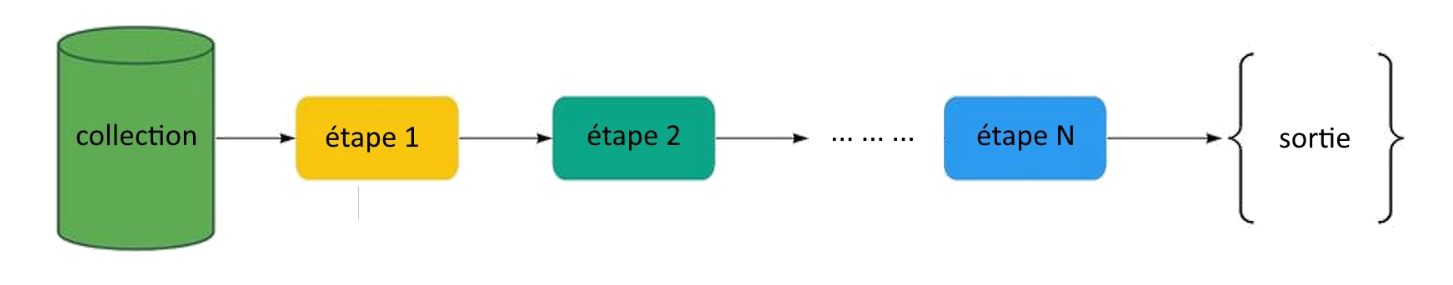

## Pré-requis

Démarrer votre container mongosingle si il n'est pas démarré :

Vérifiez que votre container mongo est opérationnel :

Vous allez à présent charger le jeux de données movies en utilisant la commande suivante :

## Introduction

Nous utiliserons pour ce TP la collection companies dont voici un exemple de structure :

```$project```, ```$set``` et ```$unset``` sont des étapes qui vont nous permettre de transformer la structure d'un document.

# Comment transformer un document ?

L'opérateur `$project` est utilisé pour sélectionner et inclure spécifiquement certains champs dans les documents de sortie d'une agrégation. Par défaut, si un champ n'est pas explicitement inclus dans `$project`, il ne sera pas présent dans le document résultant, ce qui permet de réduire la consommation de mémoire RAM des documents traités. Cela est similaire à la fonctionnalité de projection dans la méthode `find`, où le second argument spécifie les champs à inclure ou à exclure.

Voici un exemple où la projection est limitée uniquement aux champs `name` et `offices` :

```
db.collection.aggregate([
    {
        $project: {
            _id: 0, // Exclure le champ _id
            name: 1, // Inclure le champ name
            offices: 1 // Inclure le champ offices
        }
    }
])
```


L'étape ```$set```aura le comportement inverse à ```$project```, il affichera tous les champs par défaut.

Si on souhaite rajouter des champs additionnels :

Gràce à ```$project```, ```$set``` et ```$unset```, on peut réorganiser les documents sous la forme que l'on souhaite.
Dans cet exemple, on crée un sous document deadpool qui regroupe tous les attributs préfixés par deadpool :
* deadpooled_year
* deadpooled_month
* deadpooled_day.

Pour obtenir le même résultat avec ```$set``` et ```$unset```, le code est plus complexe du fait qu'on doit exprimer la suppression d'une grande majorité des champs.

Attention, la projection sur une clé de type tableau implique que la nouvelle clé de projection sera elle même un tableau.
Un exemple sera sûrement plus parlant ;-).

L'exemple ci-dessous regroupe l'ensemble des noms de produits dans un champs products_name de type tableau.


Pour aider dans la transformation et le traitement d'un document, MongoDB intègre un ensemble d'opérateurs qui donne beaucoup de flexibilité.

Le détail des opérateurs est disponible ici :

https://docs.mongodb.com/manual/reference/operator/aggregation/


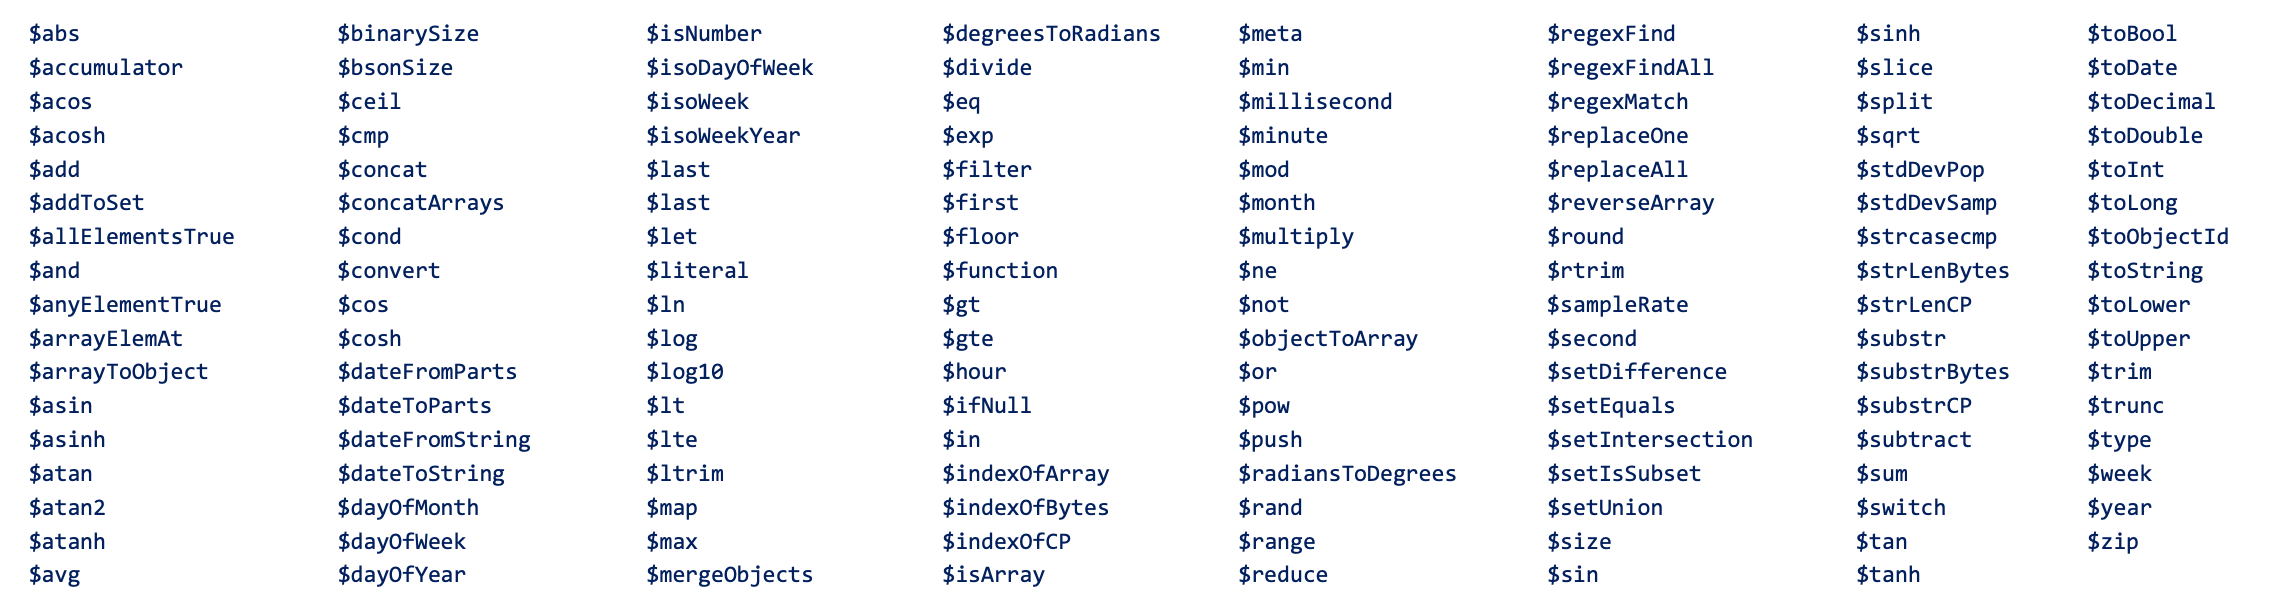

La liste est trop longue pour tous les introduire, on trouvera notamment un opérateur de condition ```$cond``` qui permet de réaliser des traitements distincts suivant l'évaluation d'une condition.
Dans l'exemple ci-dessous, on emploie ```$isArray```, ```$size``` et ```$cond``` pour conditionner la structure du document.

Recherchez le nombre d'investissements qu'ont réalisé les entreprises acquises pour plus de 10 millions de $ ?


Le résultat d'une transformation peut être retourné au client ou être enregistré dans une collection grâce à la stage ```$out``` ou ```$merge```.

```$out``` va tout simplement nous permettre de stocker le résultat d'un traitement dans une nouvelle collection. Si la collection existe déjà, il supprime son contenu avant de ré-insérer le résultat.

https://docs.mongodb.com/manual/reference/operator/aggregation/out/

```$merge``` est le moyen de fusionner différents traitements dans une même collection.
Ajoutons dans notre collection myoutputfromscratch, les entreprises dont les investissements sont entre 3 et 4.

Les resultats ont été ajoutés sans supprimer le contenu existant.

## Exercice

Vous allez dans cette exerice travailler avec la collection trips.
Cette collection contient les déplacements des véliv à NY.

La structure d'un document est la suivante :

#### <font color='red'>A partir du pipeline d'agrégation, utilisez `$project`pour transformer les documents de manière à ce que :</font>

```{note} Note

Les propriétés d'un biker seront réunies dans un objet biker.

```



Vous trouverez ci-dessous un exemple de résultat :

#### <font color='red'>Réalisez la même opération mais cette fois-ci avec les étapes ```$set``` et ```$unset``` :</font>

https://docs.mongodb.com/manual/reference/operator/aggregation/set/

https://docs.mongodb.com/manual/reference/operator/aggregation/unset/#mongodb-pipeline-pipe.-unset

#### <font color='red'>Utilisez `$unset` et `$set` pour transformer les documents de manière à ce que : </font>
```{note} Note

Les propriétés d'une station ( start/end station id/name )  seront contenues dans l'objet start/end station location.
```

#### <font color='red'> Construisez à partir de la collection `trips`, une collection `stations` constituant l'ensemble des stations disponibles et donc la structure sera celle indiquée ci-dessous :</font>


```{note} Note
* Attention, les stations de départ peuvent aussi être des stations d'arrivée par conséquent il faudra supprimer les doublons.
```


```{hint} Indice
Executer une commande avec agregate pour les stations de départ et une autre pour les stations pour l'arrivée.

```

Pour être sûre que notre collection contiendra la structure minimale citée ci-dessous, on peut associer le schema suivant à la collection stations :


La commande ci-dessus sera explicitée dans la section suivante.

#### <font color='red'>Créez une collection trips2 qui ne contiendra plus les propriétés des stations à l'exception de ```end station id``` et ```start station id``` </font>

Voici un exemple des documents contenus dans trips2 :

#### <font color='red'>A partir des collections strip2 et stations, réalisez la jointure qui permette de définir la station d'arrivée et de départ du bikeid 17827  </font>

```{note} Note
Utisez l'opérateur $lookup. 

https://docs.mongodb.com/manual/reference/operator/aggregation/lookup/
```

On pourra vérifier dans la collection strips les stations de départ pour un trajet spécifique (_id)

Super !!! 
Nous pouvons reconstituer le contenu de notre trip en passant par les références.


# Conclusion

Au cours de ce TP, nous avons exploré les fonctionnalités de MongoDB qui facilitent la transformation des collections pour en simplifier l'utilisation. Vous avez travaillé sur une collection initiale `zips`, qui contenait des doublons pour les stations de départ et d'arrivée, et vous l'avez scindée en deux collections distinctes : `zips2` et `station`. Cette séparation nous oblige pour requêter nos données à utiliser le principe de jointure entre les deux collections, une opération qui peut potentiellement ralentir les performances. 

Bien que MongoDB offre la flexibilité de réaliser ces jointures, il est important de noter que la cohérence des données n'est pas garantie. En effet, MongoDB ne possède pas de mécanismes de contrainte d'intégrité (clé étrangère) pour s'assurer que les références aux stations de départ et d'arrivée dans la collection `trips2` existe bien dans la colelction `station`.
